In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Retail and wherehouse Sale.csv')

In [ ]:
df.head(10)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0
5,2020,1,KYSELA PERE ET FILS LTD,100641,CORTENOVA VENETO P/GRIG - 750ML,WINE,2.76,0.0,6.0
6,2020,1,SANTA MARGHERITA USA INC,100749,SANTA MARGHERITA P/GRIG ALTO - 375ML,WINE,0.08,1.0,1.0
7,2020,1,BROWN-FORMAN BEVERAGES WORLDWIDE,1008,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...,BEER,0.00,0.0,2.0
8,2020,1,JIM BEAM BRANDS CO,10103,KNOB CREEK BOURBON 9YR - 100P - 375ML,LIQUOR,6.41,4.0,0.0
9,2020,1,INTERNATIONAL CELLARS LLC,101117,KSARA CAB - 750ML,WINE,0.33,1.0,2.0


In [ ]:
df.shape

(30000, 9)

In [ ]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              30000 non-null  int64  
 1   MONTH             30000 non-null  int64  
 2   SUPPLIER          29967 non-null  object 
 3   ITEM CODE         30000 non-null  object 
 4   ITEM DESCRIPTION  30000 non-null  object 
 5   ITEM TYPE         30000 non-null  object 
 6   RETAIL SALES      29999 non-null  float64
 7   RETAIL TRANSFERS  30000 non-null  float64
 8   WAREHOUSE SALES   30000 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.1+ MB


In [ ]:
df.isnull().sum()

,0
YEAR,0
MONTH,0
SUPPLIER,33
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,0
RETAIL SALES,1
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


In [ ]:
df = df.dropna()

In [ ]:
df['MONTH_NAME'] = pd.to_datetime(df['MONTH'], format='%m').dt.month_name()

In [ ]:
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str))

In [ ]:
df['TOTAL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

In [ ]:
df.head(10)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,MONTH_NAME,DATE,TOTAL SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,January,2020-01-01,2.00
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,January,2020-01-01,4.00
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,January,2020-01-01,1.00
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,January,2020-01-01,1.00
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,January,2020-01-01,0.82
5,2020,1,KYSELA PERE ET FILS LTD,100641,CORTENOVA VENETO P/GRIG - 750ML,WINE,2.76,0.0,6.0,January,2020-01-01,8.76
6,2020,1,SANTA MARGHERITA USA INC,100749,SANTA MARGHERITA P/GRIG ALTO - 375ML,WINE,0.08,1.0,1.0,January,2020-01-01,1.08
7,2020,1,BROWN-FORMAN BEVERAGES WORLDWIDE,1008,JACK DANIELS COUNTRY COCKTAIL SOUTHERN PEACH -...,BEER,0.00,0.0,2.0,January,2020-01-01,2.00
8,2020,1,JIM BEAM BRANDS CO,10103,KNOB CREEK BOURBON 9YR - 100P - 375ML,LIQUOR,6.41,4.0,0.0,January,2020-01-01,6.41
9,2020,1,INTERNATIONAL CELLARS LLC,101117,KSARA CAB - 750ML,WINE,0.33,1.0,2.0,January,2020-01-01,2.33


In [ ]:
df['TOTAL SALES'].sum()

np.float64(1028499.3899999999)

In [ ]:
df['RETAIL SALES'].sum()

np.float64(204223.46000000002)

In [ ]:
df['WAREHOUSE SALES'].sum()

np.float64(824275.9299999999)

In [ ]:
monthly_sales = df.groupby('MONTH_NAME')['TOTAL SALES'].sum()
monthly_sales

,TOTAL SALES
MONTH_NAME,
January,358963.32
July,510087.02
March,147227.46
September,12221.59


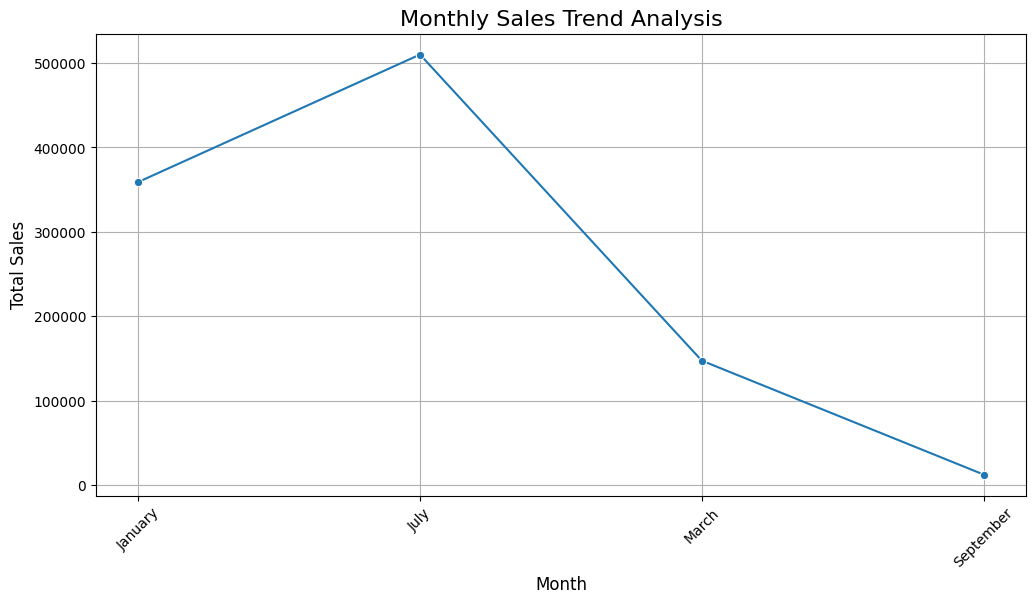

In [ ]:
monthly_sales = df.groupby('MONTH_NAME')['TOTAL SALES'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='MONTH_NAME', y='TOTAL SALES', marker='o')

plt.title("Monthly Sales Trend Analysis", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

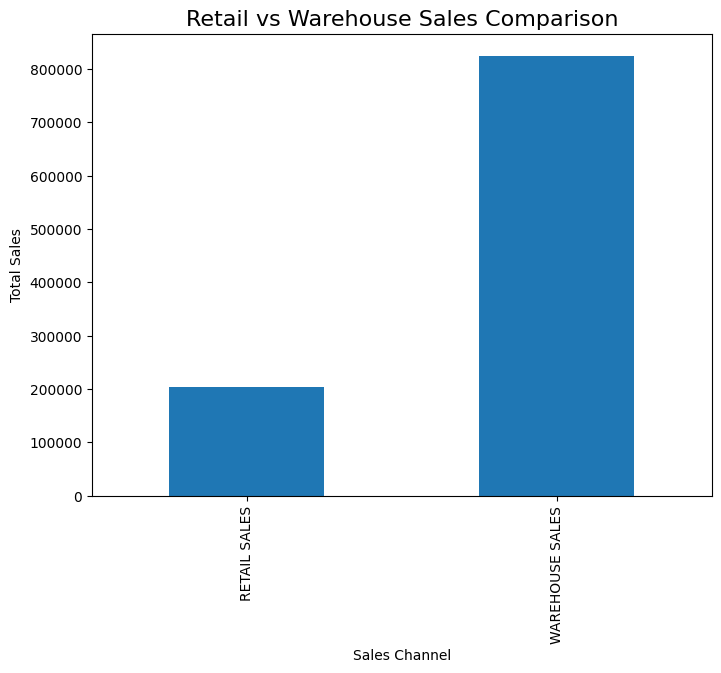

In [ ]:
sales_channel = df[['RETAIL SALES','WAREHOUSE SALES']].sum()

plt.figure(figsize=(8,6))
sales_channel.plot(kind='bar')

plt.title("Retail vs Warehouse Sales Comparison", fontsize=16)
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales")

plt.show()

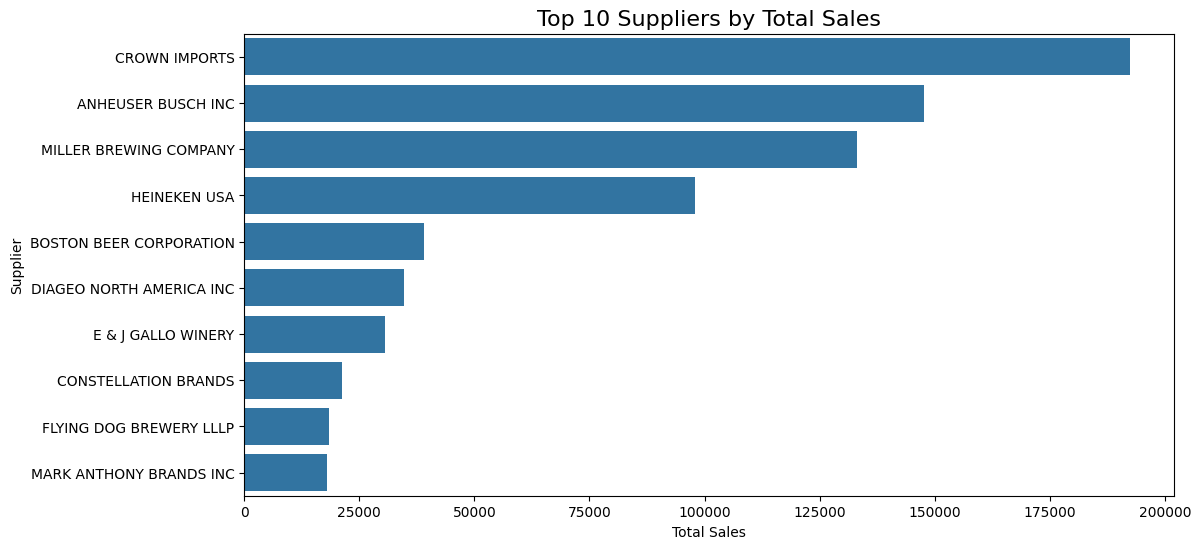

In [ ]:
top_suppliers = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_suppliers.values, y=top_suppliers.index)

plt.title("Top 10 Suppliers by Total Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Supplier")

plt.show()

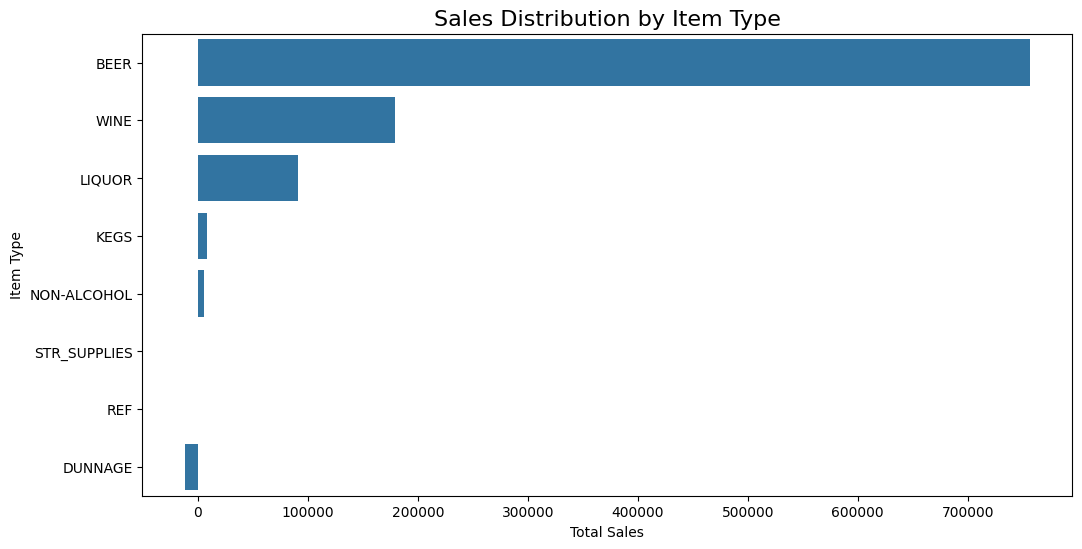

In [ ]:
item_sales = df.groupby('ITEM TYPE')['TOTAL SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=item_sales.values, y=item_sales.index)

plt.title("Sales Distribution by Item Type", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Item Type")

plt.show()

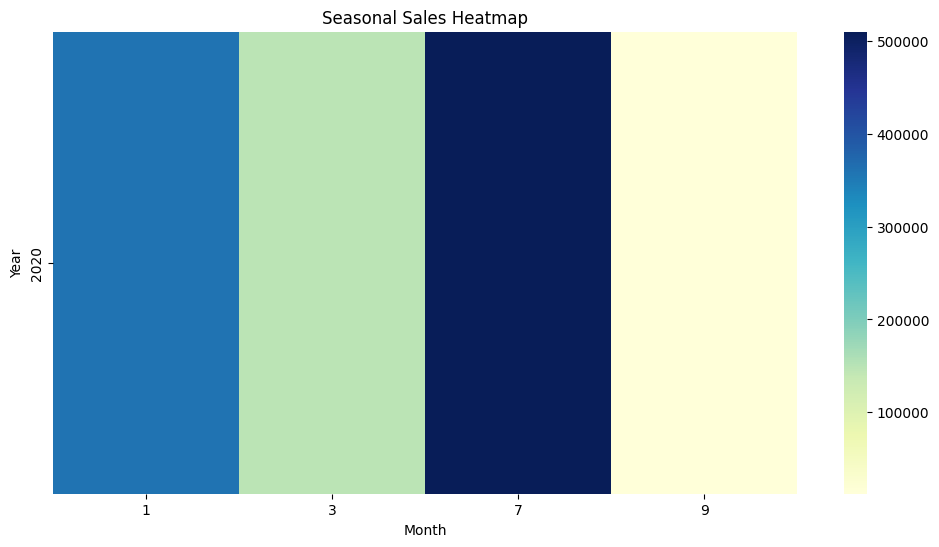

In [ ]:
pivot_table = df.pivot_table(values='TOTAL SALES', index='YEAR', columns='MONTH', aggfunc='sum')

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=False)

plt.title("Seasonal Sales Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

In [ ]:
df.to_csv('Retail_Cleaned_Data.csv', index=False)

In [ ]:
from google.colab import files
files.download('Retail_Cleaned_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>